In [1]:
#librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import holidays as hld

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler #Para estandarizar
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, RidgeCV, Lasso, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import sklearn.metrics as metrics

In [2]:
# carga del archivo
uber = pd.read_csv('uber_fares.csv')

## Analisis descriptivo

In [3]:
uber.info() #200000 registros

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Convertimos los datos de fecha, a su dato correspondiente

In [4]:
uber['date'] = pd.to_datetime(uber['date'])
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

In [5]:
uber.describe()

,key,date,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,2012-03-22 15:02:18.433115648,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
min,1.000000e+00,2009-01-01 01:15:22.000000600,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,2010-08-25 08:20:16,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,2012-03-21 20:44:29.500000256,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,2013-10-19 02:14:16.500000512,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,2015-06-30 23:40:39.000000100,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000
std,1.601382e+07,NaN,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997


### Creación de nuevas variables

In [6]:
def distancia(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))

In [7]:
uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

uber["rango_pasajeros"] = uber["passenger_count"].apply(lambda x: "0" if x == 0 else ("1-4" if 1 <= x <= 4 else "5+"))

uber["hora"] = uber["pickup_datetime"].dt.hour
uber["fecha"] = uber["pickup_datetime"].dt.date
uber["día"] = uber["pickup_datetime"].dt.day_name()
uber["num_dia"] = uber["pickup_datetime"].dt.weekday

uber["rango_hora"] = uber["hora"].apply(lambda x: "mañana" if 6 <= x <= 12 else ("tarde" if 13 <= x <= 18 else ("noche" if 19 <= x <=23 else "madrugada")))
uber["tipo_dia"] = uber["num_dia"].apply(lambda x: "1" if x in [0, 1, 2, 3, 4] else "0")

dummies_rango_hora = pd.get_dummies(uber["rango_hora"], prefix="hora", drop_first=True)
dummies_rango_pasajero = pd.get_dummies(uber["rango_pasajeros"], prefix="pasajero", drop_first=True)
uber = pd.concat([uber, dummies_rango_hora, dummies_rango_pasajero], axis=1)

us_holidays = hld.US()
us_holidays = hld.country_holidays('US')

nyse_holidays = hld.NYSE()
nyse_holidays = hld.financial_holidays('NYSE')

uber["feriado"] = uber["fecha"].apply(lambda x: x in us_holidays or x in nyse_holidays)

### División del dataset

In [8]:
X = uber.drop(labels='fare_amount', axis=1)

# Target
y = uber["fare_amount"].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.describe()

,key,date,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia,hora,num_dia
count,1.600000e+05,160000,160000.000000,160000.000000,159999.000000,159999.000000,160000.000000,159999.000000,160000.000000,160000.000000
mean,2.771233e+07,2012-03-22 02:59:10.791006464,-72.525896,39.936265,-72.525260,39.919258,1.684988,12.794774,13.483950,3.049387
min,1.000000e+00,2009-01-01 01:15:22.000000600,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000,0.000000,0.000000,0.000000
25%,1.379326e+07,2010-08-24 21:11:25.250000128,-73.992062,40.734842,-73.991433,40.733835,1.000000,0.756791,9.000000,1.000000
50%,2.775608e+07,2012-03-21 17:29:17.500000512,-73.981834,40.752594,-73.980080,40.753044,1.000000,1.320600,14.000000,3.000000
75%,4.155845e+07,2013-10-18 07:11:55,-73.967212,40.767116,-73.963614,40.768055,2.000000,2.407452,19.000000,5.000000
max,5.542357e+07,2015-06-30 23:40:39.000000100,57.418457,1644.421482,1153.572603,872.697628,208.000000,10196.228613,23.000000,6.000000
std,1.603218e+07,NaN,11.557753,8.090121,13.611271,6.880320,1.405686,236.462222,6.514851,1.947462


### Valores atipicos

In [9]:
print(f"Viajes con costos negativos: {y_train[y_train <= 0].count()}")
# hay 17 valores negativos y 5 con valor 0

Viajes con costos negativos: 19


In [10]:
y_train[y_train > 0].count()

np.int64(159981)

In [11]:
# Reemplazar valores 0 por NaN (porque son inválidos)
columnas_coords = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
X_train[columnas_coords] = X_train[columnas_coords].replace(0, np.nan)

# Reemplazar valores fuera de rango (latitudes: -90 a 90, longitudes: -180 a 180)
# Rango realista de coordenadas para NYC
lat_min, lat_max = 40.5, 41.0
lon_min, lon_max = -74.3, -73.5

for col in columnas_coords:
    if 'latitude' in col:
        X_train.loc[(X_train[col] < lat_min) | (X_train[col] > lat_max), col] = np.nan
    elif 'longitude' in col:
        X_train.loc[(X_train[col] < lon_min) | (X_train[col] > lon_max), col] = np.nan

# Reemplazar distancia inválida por NaN y distancias muy bajas
X_train['distancia'] = X_train['distancia'].apply(lambda x: np.nan if x <= 0.1 else x)

# Eliminar outliers de distancia (basado en IQR)
q1 = X_train["distancia"].quantile(0.25)
q3 = X_train["distancia"].quantile(0.75)
iqr = q3 - q1
limite_inferior = max(q1 - 1.5 * iqr, 0)
limite_superior = q3 + 1.5 * iqr

X_train['distancia'] = X_train['distancia'].apply(lambda x: np.nan if x < limite_inferior or x > limite_superior else x)

# Reemplazar valor imposible en cantidad de pasajeros
X_train.loc[X_train['passenger_count'] > 30, 'passenger_count'] = np.nan

# Eliminar tarifas <= 0
X_train = X_train[y_train > 0]
y_train = y_train[y_train > 0]

# Eliminar outliers de tarifa
X_train.drop(X_train[y_train > 300].index, inplace=True)
y_train.drop(y_train[y_train > 300].index, inplace=True)

# MOSTRAR VALORES FALTANTES
X_train.isna().sum()

key                      0
date                     0
pickup_datetime          0
pickup_longitude      3250
pickup_latitude       3243
dropoff_longitude     3215
dropoff_latitude      3231
passenger_count          1
distancia            18694
rango_pasajeros          0
hora                     0
fecha                    0
día                      0
num_dia                  0
rango_hora               0
tipo_dia                 0
hora_mañana              0
hora_noche               0
hora_tarde               0
pasajero_1-4             0
pasajero_5+              0
feriado                  0
dtype: int64

In [12]:
# Chequeamos el % de datos eliminados

porcentaje_eliminados = round((160000- len(X_train)) / 160000 * 100, 2)
print(f"Se eliminaron el {porcentaje_eliminados}% de los datos")

Se eliminaron el 0.01% de los datos


In [13]:
# Diagnóstico: coordenadas aún inválidas (NaN o 0)

columnas_coords = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']

# Condición: al menos una coordenada es NaN o igual a 0
condicion_nan = X_train[columnas_coords].isna().any(axis=1)
condicion_cero = (X_train[columnas_coords] == 0).any(axis=1)

# Filas que cumplen alguna de las dos condiciones
filas_con_problemas = X_train[condicion_nan | condicion_cero]

# Mostrar las filas con problemas en las coordenadas
filas_con_problemas[columnas_coords]

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
67739,NaN,NaN,NaN,NaN
150766,NaN,NaN,NaN,NaN
112198,NaN,NaN,NaN,NaN
82975,NaN,NaN,NaN,NaN
173687,NaN,NaN,NaN,NaN
...,...,...,...,...
139752,NaN,NaN,NaN,NaN
61087,NaN,NaN,NaN,NaN
174013,NaN,NaN,NaN,NaN
104488,NaN,NaN,NaN,NaN


In [14]:
X_train[X_train["distancia"].isna()]

,key,date,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia,rango_pasajeros,...,día,num_dia,rango_hora,tipo_dia,hora_mañana,hora_noche,hora_tarde,pasajero_1-4,pasajero_5+,feriado
67802,54334677,2013-02-27 22:29:15.000000400,2013-02-27 22:29:15+00:00,-73.978198,40.752533,-73.909752,40.874372,1.0,NaN,1-4,...,Wednesday,2,noche,1,False,True,False,True,False,False
104681,54482655,2013-09-29 13:36:00.000000167,2013-09-29 13:36:00+00:00,-73.989120,40.736932,-73.782890,40.643947,1.0,NaN,1-4,...,Sunday,6,tarde,0,False,False,True,True,False,False
38121,37600505,2012-12-04 23:59:10.000000400,2012-12-04 23:59:10+00:00,-73.954318,40.774471,-73.848278,40.723035,1.0,NaN,1-4,...,Tuesday,1,noche,1,False,True,False,True,False,False
84264,43332049,2009-05-13 01:51:58.000000100,2009-05-13 01:51:58+00:00,-73.974360,40.742586,-73.936676,40.812422,1.0,NaN,1-4,...,Wednesday,2,madrugada,1,False,False,False,True,False,False
67739,38703576,2013-04-10 23:45:47.000000100,2013-04-10 23:45:47+00:00,NaN,NaN,NaN,NaN,1.0,NaN,1-4,...,Wednesday,2,noche,1,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130608,42294353,2011-11-26 08:04:00.000000220,2011-11-26 08:04:00+00:00,-73.984535,40.745927,-73.984500,40.746030,2.0,NaN,1-4,...,Saturday,5,mañana,0,True,False,False,True,False,False
64820,18842521,2010-09-06 12:12:00.000000117,2010-09-06 12:12:00+00:00,-73.977917,40.742090,-73.977862,40.742167,3.0,NaN,1-4,...,Monday,0,mañana,1,True,False,False,True,False,True
41090,28203281,2012-03-06 11:27:00.000000800,2012-03-06 11:27:00+00:00,-74.003225,40.727617,-73.785148,40.643162,1.0,NaN,1-4,...,Tuesday,1,mañana,1,True,False,False,True,False,False
126324,36335414,2010-08-13 11:40:50.000000200,2010-08-13 11:40:50+00:00,-73.788948,40.642273,-74.017192,40.705278,1.0,NaN,1-4,...,Friday,4,mañana,1,True,False,False,True,False,False


### Valores Nulos

In [15]:
X_train.isna().sum()

key                      0
date                     0
pickup_datetime          0
pickup_longitude      3250
pickup_latitude       3243
dropoff_longitude     3215
dropoff_latitude      3231
passenger_count          1
distancia            18694
rango_pasajeros          0
hora                     0
fecha                    0
día                      0
num_dia                  0
rango_hora               0
tipo_dia                 0
hora_mañana              0
hora_noche               0
hora_tarde               0
pasajero_1-4             0
pasajero_5+              0
feriado                  0
dtype: int64

In [16]:
def grafico_texto(title: str, 
                  xlabel: str, 
                  ylabel: str,
                  grid : bool = False,
                  yticks : bool = False,
                  labels : list = [],
                  range_ticks : int = 0,
                  axhline: bool = False,
                  legend: bool = False,
                  tight_layout: bool = False,
                 ):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if grid:
        plt.grid(grid)
    if yticks:
        plt.yticks(ticks=[i + 0.5 for i in range(range_ticks)], labels=labels, rotation=0)
    if axhline:
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    if legend:
        plt.legend(loc='best', frameon=False)
    if tight_layout:
        plt.tight_layout()
    plt.show()

In [17]:
def grafico_scatterplot(data : pd.DataFrame,
                        x: str,
                        y: str,
                        title: str,
                        xlabel: str,
                        ylabel: str,
                        grid: bool
                        ):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x=x, y=y,alpha = 0.3, s = 10)
    grafico_texto(title, xlabel, ylabel, grid)

In [18]:
def grafico_lmplot(data : pd.DataFrame,
                  x: str,
                  y: str,
                  title: str,
                  xlabel: str,
                  ylabel: str,
                  grid: bool
                  ):
    sns.lmplot(data=data, x=x, y=y, aspect=2, height=6, scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
    grafico_texto(title, xlabel, ylabel, grid)

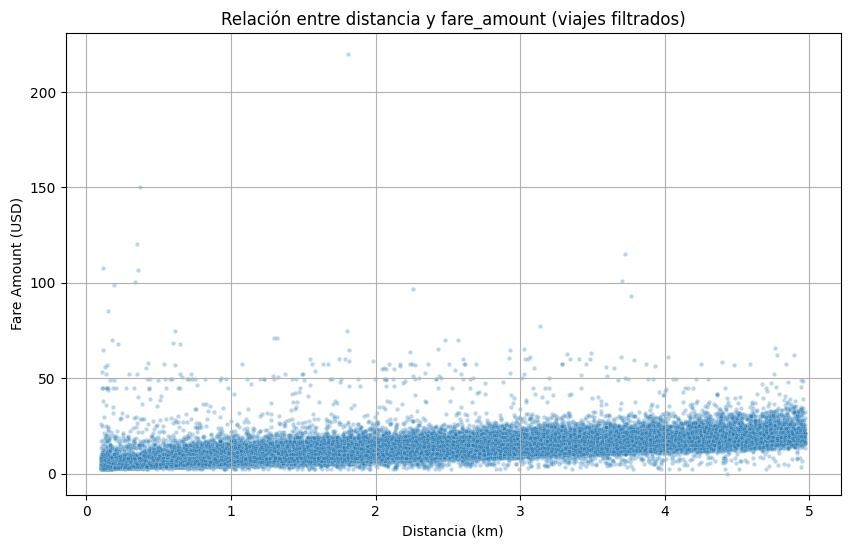

In [19]:
# Grafico fare amount ANTES de la imputación

grafico_scatterplot(X_train, "distancia", y_train,
                    "Relación entre distancia y fare_amount (viajes filtrados)",
                    "Distancia (km)",
                    "Fare Amount (USD)",
                    True)

In [ ]:
# Definir las columnas a imputar
columnas_a_imputar = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

# Copia del dataset para trabajar con las imputaciones
X_train_imputed = X_train.copy()

# Reemplazar valores 0 por NaN
for col in columnas_a_imputar:
    X_train_imputed[col] = X_train_imputed[col].replace(0, np.nan)

# Imputador para medias
mean_imputer = SimpleImputer(strategy='mean')

# Imputador para KNN
knn_imputer = KNNImputer(n_neighbors=5)

# Crear un booleano para filas con coordenadas faltantes
coordenadas_faltantes = X_train_imputed[columnas_a_imputar].isnull().sum(axis=1)

# Caso 1: Una sola coordenada es 0
caso_1_mask = (coordenadas_faltantes == 1)
if not X_train_imputed.loc[caso_1_mask, columnas_a_imputar].empty:
    imputados_caso_1 = knn_imputer.fit_transform(X_train_imputed.loc[caso_1_mask, columnas_a_imputar])
    X_train_imputed.loc[caso_1_mask, columnas_a_imputar] = imputados_caso_1

# Caso 2: Dos coordenadas son 0
caso_2_mask = (coordenadas_faltantes == 2)
if not X_train_imputed.loc[caso_2_mask, columnas_a_imputar].empty:
    imputados_caso_2 = mean_imputer.fit_transform(X_train_imputed.loc[caso_2_mask, columnas_a_imputar])
    X_train_imputed.loc[caso_2_mask, columnas_a_imputar] = imputados_caso_2

# Caso 3: Tres o cuatro coordenadas son 0
caso_3_mask = (coordenadas_faltantes >= 3)
if not X_train_imputed.loc[caso_3_mask, columnas_a_imputar].empty:
    imputados_caso_3 = mean_imputer.fit_transform(X_train_imputed.loc[caso_3_mask, columnas_a_imputar])
    for idx, col in enumerate(columnas_a_imputar):
        X_train_imputed.loc


X_train = X_train_imputed # ACORDARSE DE ARREGLAR ESTO

X_train_imputed[X_train_imputed.isna().any(axis=1)]

c:\Users\grima\Desktop\UNR\TUIA\4° cuatri\APRENDIZAJE AUTOMATICO\PRACTICA\.venv\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['pickup_longitude']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [21]:
# Imputo el único valor NaN de passenger_count

X_train[X_train["passenger_count"].isna()] = X_train["passenger_count"].median()

C:\Users\grima\AppData\Local\Temp\ipykernel_20168\1192577110.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  X_train[X_train["passenger_count"].isna()] = X_train["passenger_count"].median()
C:\Users\grima\AppData\Local\Temp\ipykernel_20168\1192577110.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns, UTC], please explicitly cast to a compatible dtype first.
  X_train[X_train["passenger_count"].isna()] = X_train["passenger_count"].median()
C:\Users\grima\AppData\Local\Temp\ipykernel_20168\1192577110.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with bool, 

In [22]:
# # Recalculo la distancia despúes de haber imputado

# uber["distancia"] = distancia(
#     uber["pickup_latitude"],
#     uber["pickup_longitude"],
#     uber["dropoff_latitude"],
#     uber["dropoff_longitude"]
# )


### Graficos

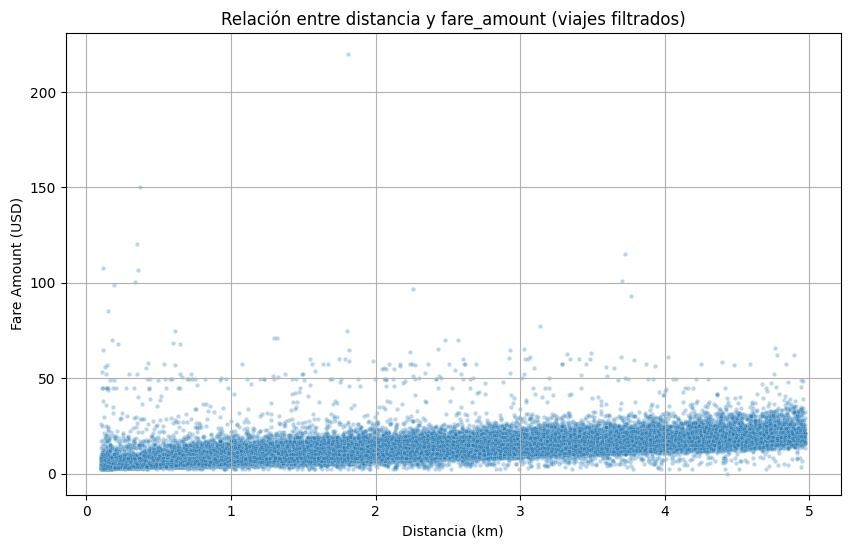

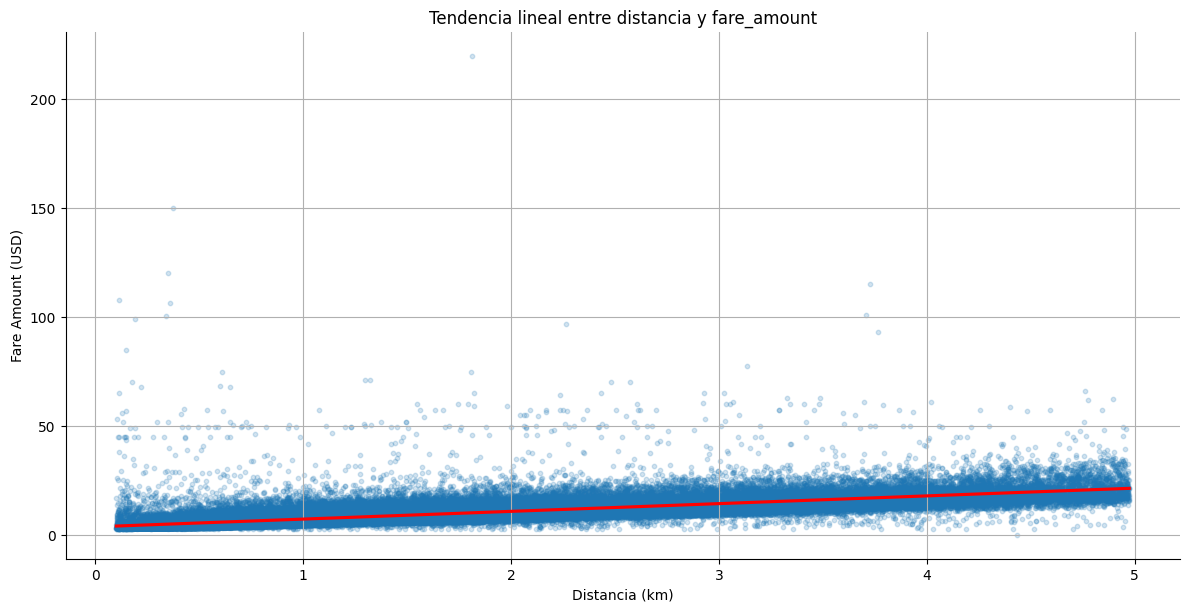

In [23]:
# Grafico fare amount DESPUÉS de la imputación

df_temp = pd.DataFrame({
    "distancia": X_train["distancia"],
    "fare_amount": y_train
})

grafico_scatterplot(X_train, "distancia", y_train,
                    "Relación entre distancia y fare_amount (viajes filtrados)",
                    "Distancia (km)",
                    "Fare Amount (USD)",
                    True)

grafico_lmplot(df_temp, "distancia", "fare_amount",
                    "Tendencia lineal entre distancia y fare_amount",
                    "Distancia (km)",
                    "Fare Amount (USD)",
                    True)


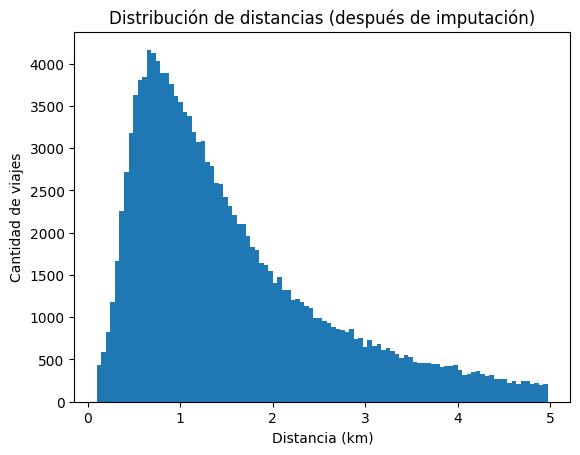

In [24]:
# Distribución de las distancias después de la imputación

plt.hist(X_train['distancia'], bins=100)
grafico_texto(title = "Distribución de distancias (después de imputación)",
                xlabel = "Distancia (km)",
                ylabel="Cantidad de viajes")

### Distribución de fare_amount

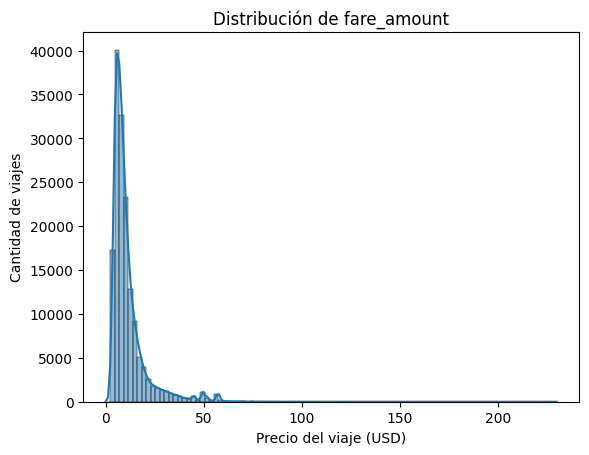

Mínimo: 0.01
Máximo: 230.0
Promedio: 11.352416864608077
Desvío estándar: 9.754331802520639


In [25]:
sns.histplot(y_train, bins=100, kde=True)
grafico_texto("Distribución de fare_amount",
                 "Precio del viaje (USD)",
                 "Cantidad de viajes")

print("Mínimo:", y_train.min())
print("Máximo:", y_train.max())
print("Promedio:", y_train.mean())
print("Desvío estándar:", y_train.std())

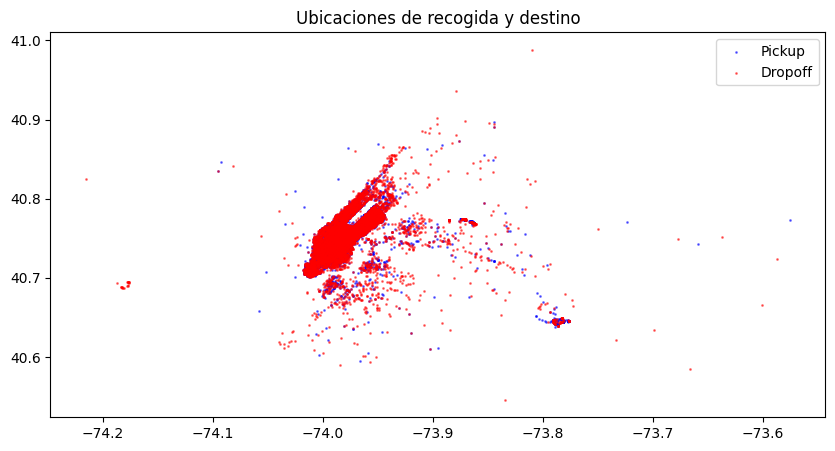

In [26]:
# Muestra una parte del dataset para evitar sobrecarga visual
sample = X_train.sample(10000)
plt.figure(figsize=(10,5))
plt.scatter(sample['pickup_longitude'], sample['pickup_latitude'], c='blue', s=1, label='Pickup', alpha=0.5)
plt.scatter(sample['dropoff_longitude'], sample['dropoff_latitude'], c='red', s=1, label='Dropoff', alpha=0.5)
plt.legend()
plt.title("Ubicaciones de recogida y destino");

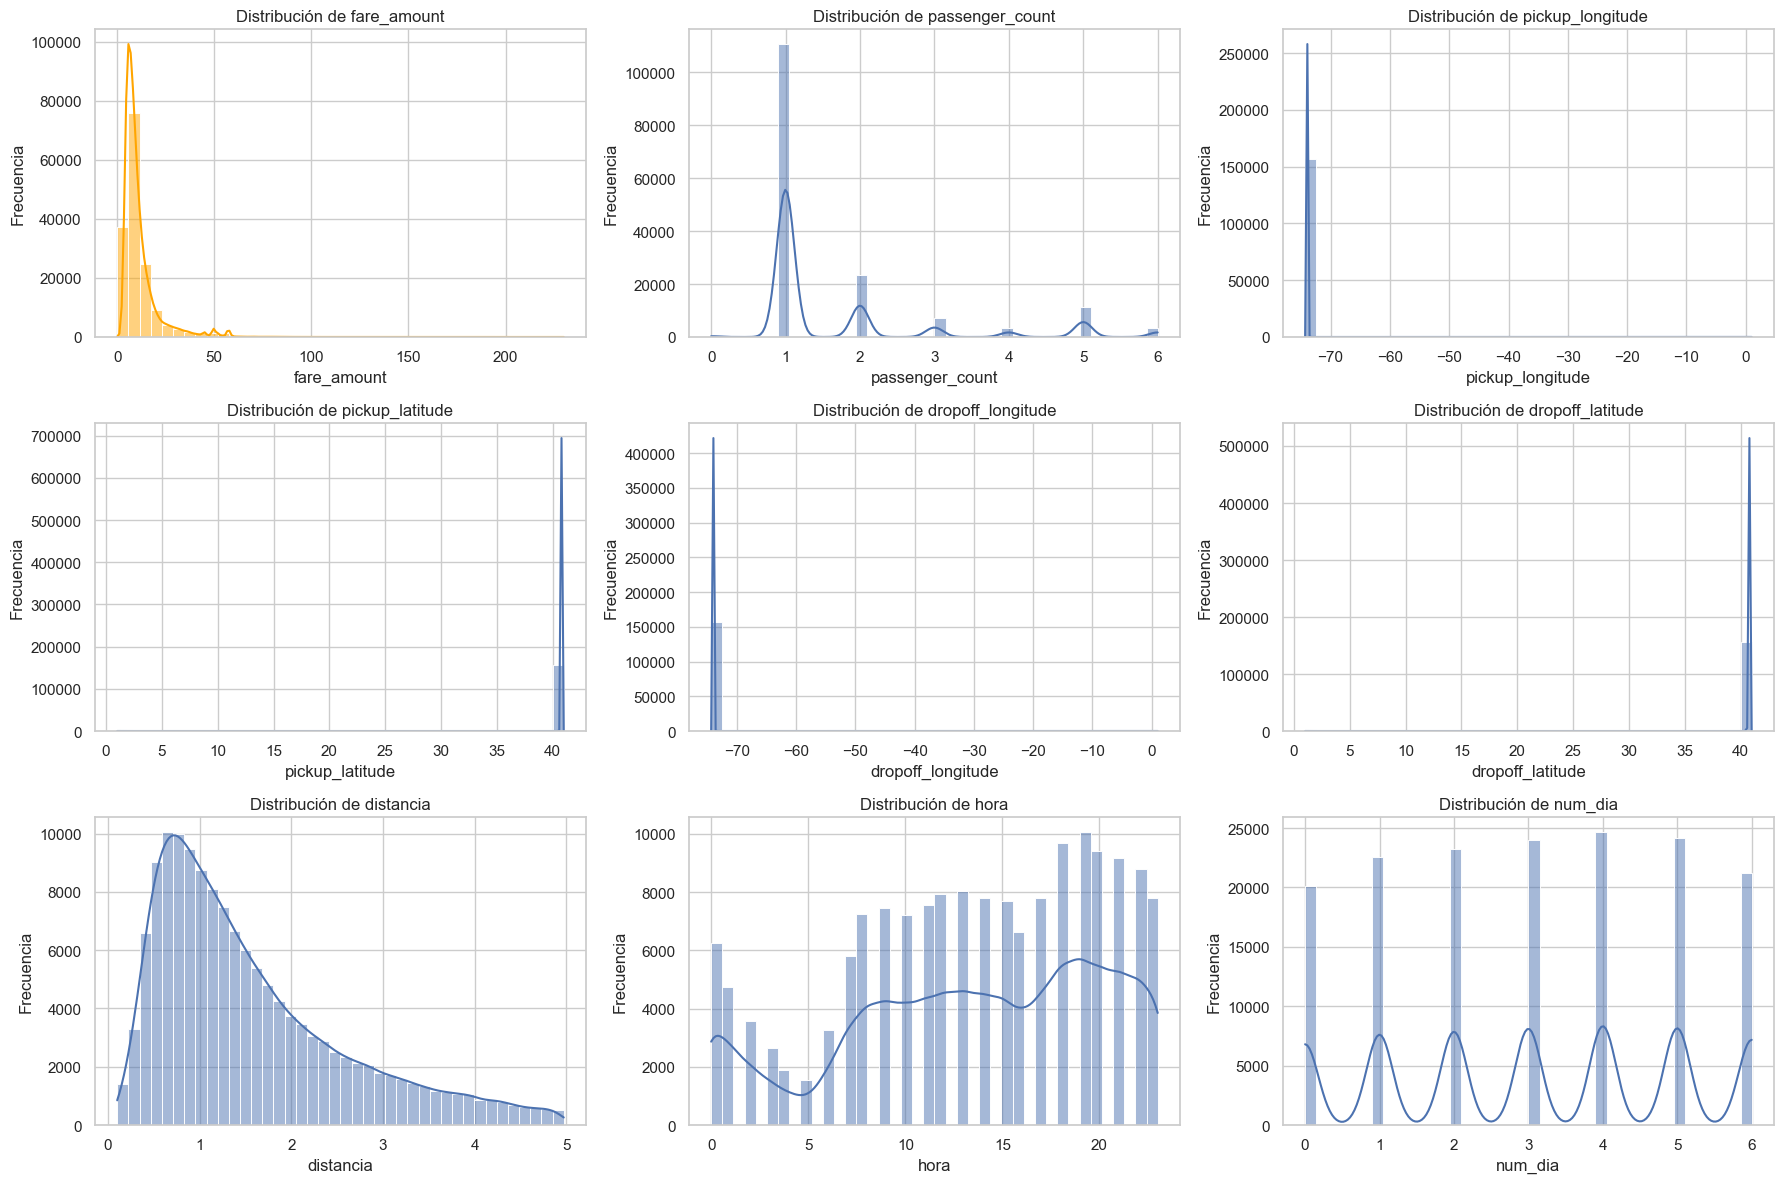

In [27]:
# Variables numéricas relevantes
variables = ["fare_amount", "passenger_count", "pickup_longitude", "pickup_latitude",
             "dropoff_longitude", "dropoff_latitude", "distancia", "hora", "num_dia"]

# Estilo
sns.set(style="whitegrid")

# Creamos los subplots
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
axs = axs.flatten()

# Generamos un histograma por cada variable
for i, col in enumerate(variables):
    if col == "fare_amount":
        sns.histplot(x=y_train, bins=40, ax=axs[i], kde=True, color='orange')
    else:
        sns.histplot(data=X_train, x=col, bins=40, ax=axs[i], kde=True)
    axs[i].set_title(f"Distribución de {col}")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

heatmap hora vs día para ver en qué momento del día hay más viajes según el día de la semana

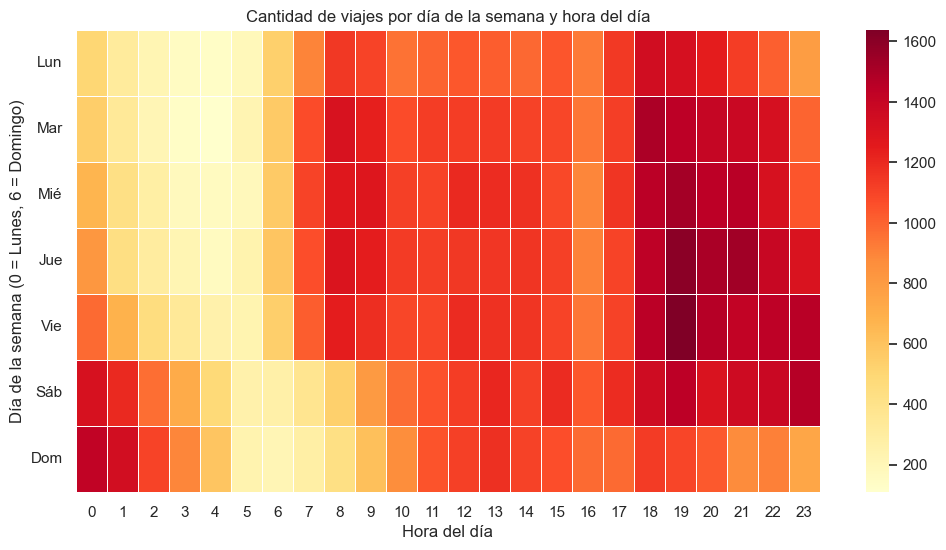

<Figure size 640x480 with 0 Axes>

In [28]:
# Creamos una tabla resumen con la cantidad de viajes por día y hora
heatmap_data = X_train.groupby(["num_dia", "hora"]).size().unstack(fill_value=0)

# Creamos el heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, linewidths=0.5)

# Títulos y etiquetas
grafico_texto("Cantidad de viajes por día de la semana y hora del día",
                 "Hora del día",
                 "Día de la semana (0 = Lunes, 6 = Domingo)",
                 False, True, ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"], 7)

plt.tight_layout()
plt.show()

fare_amount

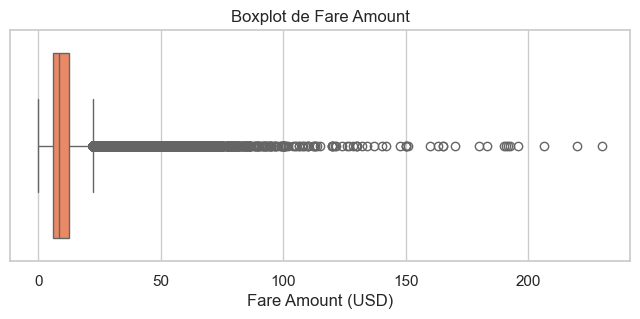

In [29]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=y_train, color="coral")
plt.title("Boxplot de Fare Amount")
plt.xlabel("Fare Amount (USD)")
plt.show()


passenger_count vs fare_amount (¿hay correlación entre los pasajeros y el precio?)

C:\Users\grima\AppData\Local\Temp\ipykernel_20168\2636962018.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_train, x="passenger_count", y=y_train, palette="Set2");


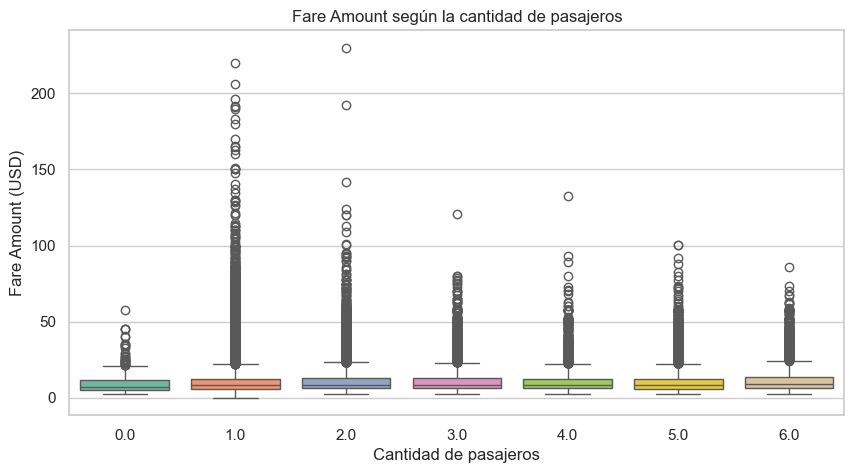

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=X_train, x="passenger_count", y=y_train, palette="Set2");
grafico_texto("Fare Amount según la cantidad de pasajeros",
              "Cantidad de pasajeros",
              "Fare Amount (USD)"
              )

In [31]:
# columnas_sin_corr = ["passenger_count", "distancia", "día", "feriado","key","fecha","date","pickup_datetime"]
# matriz = X_train.drop(columns=columnas_sin_corr)
# corr = matriz.corr()
# ax = sns.heatmap(
#     corr,
#     vmin=-1, vmax=1, center=0,
#     cmap=sns.diverging_palette(20, 220, n=200),
#     square=True,
#     annot = True,
#     annot_kws = {'size': 6}
# )
# ax.set_xticklabels(
#     ax.get_xticklabels(),
#     rotation=45,
#     horizontalalignment='right'
# )
# plt.title("Matriz de correlación")
# plt.show()

### Estandarización del dataset

In [32]:
columnas = ["tipo_dia", "feriado", "hora_mañana", "hora_tarde", "hora_noche", "pasajero_1-4","pasajero_5+"]
X_train = X_train[["distancia", "tipo_dia", "feriado", "hora_mañana", "hora_tarde", "hora_noche", "pasajero_1-4","pasajero_5+"]]
X_test = X_test[["distancia", "tipo_dia", "feriado", "hora_mañana", "hora_tarde", "hora_noche", "pasajero_1-4","pasajero_5+"]]
# Estandarizar la distancia

columnas_numericas = ["distancia"]
scaler = StandardScaler().set_output(transform="pandas")

# Escalar y resetear índice
X_scaled = scaler.fit_transform(X_train[columnas_numericas]).reset_index(drop=True)

# Concatenar con otras columnas (también con índice reseteado)
otras_columnas = X_train[columnas].reset_index(drop=True)

# Combinar todo
X_train_estandarizado = pd.concat([X_scaled, otras_columnas], axis=1)

In [33]:
X_train[X_train["distancia"].isna()]

,distancia,tipo_dia,feriado,hora_mañana,hora_tarde,hora_noche,pasajero_1-4,pasajero_5+
67802,NaN,1,False,False,False,True,True,False
104681,NaN,0,False,False,True,False,True,False
38121,NaN,1,False,False,False,True,True,False
84264,NaN,1,False,False,False,False,True,False
67739,NaN,1,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...
130608,NaN,0,False,True,False,False,True,False
64820,NaN,1,True,True,False,False,True,False
41090,NaN,1,False,True,False,False,True,False
126324,NaN,1,False,True,False,False,True,False


## Modelos de regresión

### Regresión lineal
$$
\text{fare\_amount} = 11.69 + 0.099 \cdot \text{passenger\_count} + 0.542 \cdot \text{distancia} - 0.0077 \cdot \text{feriado} + 0.0247 \cdot \text{dia} - 0.0311 \cdot \text{hora}
$$

In [34]:
modelo = LinearRegression().fit(X_train_estandarizado,y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
modelo.coef_

array([ 3.76925074e-02,  8.18298110e+00, -5.24321535e-01, -3.68784526e-02,
        6.31960253e-03])

In [ ]:
modelo.intercept_

11.39995550610114

In [ ]:
def print_metrics(y_true, y_pred, dataset=""):
    print(f"--- {dataset} ---")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred))) 
    print("MAE:", mean_absolute_error(y_true, y_pred))

In [ ]:
# Entrenamiento
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Predicciones
y_pred_train_lr = modelo_lr.predict(X_train)
y_pred_test_lr = modelo_lr.predict(X_test)

# Métricas
print_metrics(y_train, y_pred_train_lr, "Entrenamiento (Linear Regression)")
print_metrics(y_test, y_pred_test_lr, "Prueba (Linear Regression)")


--- Entrenamiento (Linear Regression) ---
R2 Score: 0.6909843963507297
MSE: 30.09004239828212
RMSE: 5.485439125382955
MAE: 2.603002593994987
--- Prueba (Linear Regression) ---
R2 Score: 0.6956972584872306
MSE: 27.82878553595284
RMSE: 5.275299568361293
MAE: 2.5774229823440242


### Gradiente descendiente

In [ ]:
sgd = SGDRegressor(loss='squared_error', penalty=None, learning_rate='invscaling', eta0=0.01, max_iter=1000, random_state=42)
sgd.fit(X_train, y_train)

y_pred_sgd_train = sgd.predict(X_train)
y_pred_sgd_test = sgd.predict(X_test)

print_metrics(y_train, y_pred_sgd_train, "Entrenamiento (SGD)")
print_metrics(y_test, y_pred_sgd_test, "Prueba (SGD)")


--- Entrenamiento (SGD) ---
R2 Score: 0.675041570707291
MSE: 31.64245688445794
RMSE: 5.625162831817221
MAE: 2.57602168361215
--- Prueba (SGD) ---
R2 Score: 0.6786021114931797
MSE: 29.392153572132916
RMSE: 5.421453086777835
MAE: 2.560642201787912


### Variación hiperparámetros de Gradiente Descendiente

In [ ]:
# Para automatizar completamente la búsqueda de hiperparámetros, usamos GridSearchCV de sklearn, le dejamos la variación 
# de eta0 y # max_iter que queremos que pruebe y nos devuelve el conjunto de hiperparametros que mejor performaron.

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDRegressor

# Definir el modelo
sgd = SGDRegressor(loss='squared_error', penalty=None, learning_rate='invscaling', random_state=42)

# Definir los hiperparámetros a explorar
param_grid = {
    'eta0': [0.001, 0.01, 0.1],
    'max_iter': [500, 1000, 2000]
}

# Configurar GridSearch
grid_search = GridSearchCV(estimator=sgd, param_grid=param_grid, scoring='r2', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Resultados
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor puntuación: {grid_search.best_score_}")

# Evaluación con los mejores hiperparámetros
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
print(f"R2 en conjunto de prueba: {r2_score(y_test, y_pred_test):.4f}\n")

print_metrics(y_test, y_pred_test, "Test (SGD) variando hiperparámetros")


Mejores hiperparámetros: {'eta0': 0.001, 'max_iter': 500}
Mejor puntuación: 0.689846775539395
R2 en conjunto de prueba: 0.6953

--- Test (SGD) variando hiperparámetros ---
R2 Score: 0.6953393471515302
MSE: 27.861516880246942
RMSE: 5.278400977592262
MAE: 2.5464976283258025


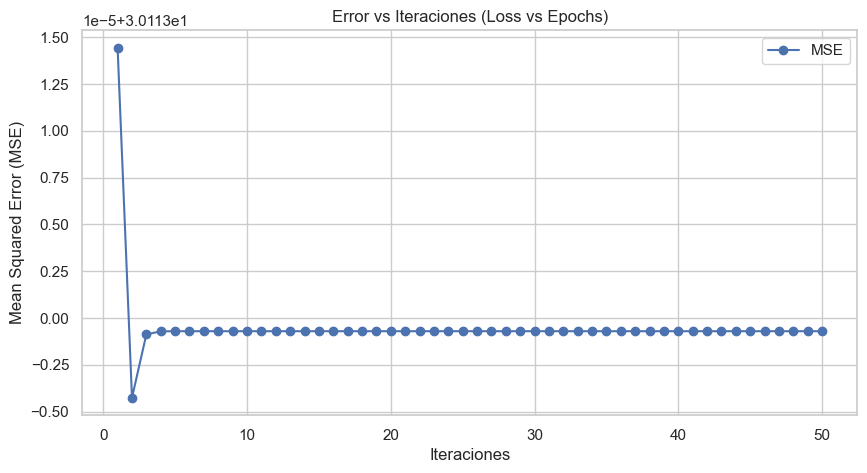

In [ ]:
# Recalculamos con los mejores hiperparámetros 'eta0': 0.001, 'max_iter': 500
# Y graficamos Error vs Iteraciones (Loss vs Epochs)

# Inicializar el modelo de nuevo con partial_fit para rastrear el error por iteración
sgd_partial = SGDRegressor(
    loss='squared_error', 
    penalty=None, 
    learning_rate='invscaling', 
    eta0=0.001, 
    max_iter=500,  # Una iteración por ajuste
    warm_start=True,  # Permite continuar ajustando
    random_state=42
)

# Lista para guardar los errores
losses = []

# Entrenamiento manual para capturar el error en cada iteración
for epoch in range(50):  # Cambiar a 1000 si quieres todas las iteraciones
    sgd_partial.fit(X_train, y_train)
    y_pred_train = sgd_partial.predict(X_train)
    mse = mean_squared_error(y_train, y_pred_train)
    losses.append(mse)

# Graficar el error vs iteraciones
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', label='MSE')
plt.title("Error vs Iteraciones (Loss vs Epochs)")
plt.xlabel("Iteraciones")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend()
plt.show()


### Ridge Regression

In [ ]:
# === CREACIÓN Y ENTRENAMIENTO DEL MODELO RIDGE CON CROSS-VALIDATION ===
modelo = RidgeCV(
    alphas=np.logspace(-10, 2, 200),
    fit_intercept=True,
    store_cv_results=True
)

_ = modelo.fit(X_train, y_train)

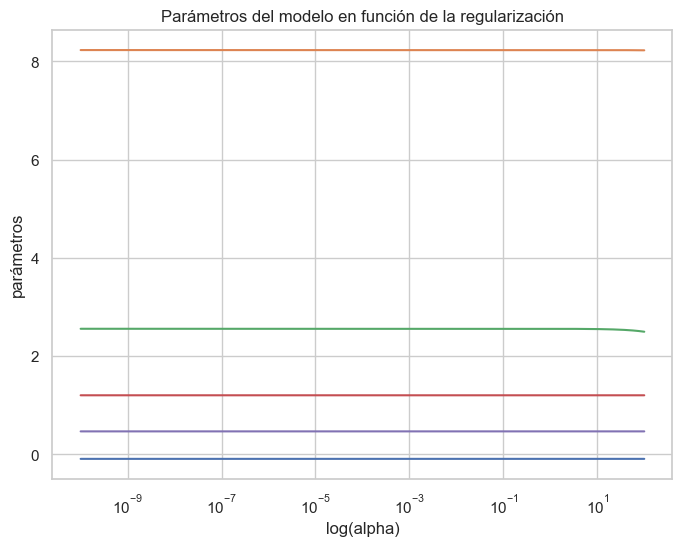

In [ ]:
# === EVOLUCIÓN DE LOS PARÁMETROS EN FUNCIÓN DE ALPHA ===
alphas = modelo.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(8, 5.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('log(alpha)')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo en función de la regularización')
plt.axis('tight')
plt.show()

In [ ]:
# === EVOLUCIÓN DEL ERROR DE VALIDACIÓN CRUZADA EN FUNCIÓN DE ALPHA ===
mse_cv = modelo.cv_results_.reshape((-1, 200)).mean(axis=0)
mse_sd = modelo.cv_results_.reshape((-1, 200)).std(axis=0)

# De MSE a RMSE
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Mejor alpha encontrado
min_rmse = np.min(rmse_cv)
optimo = modelo.alphas[np.argmin(rmse_cv)]

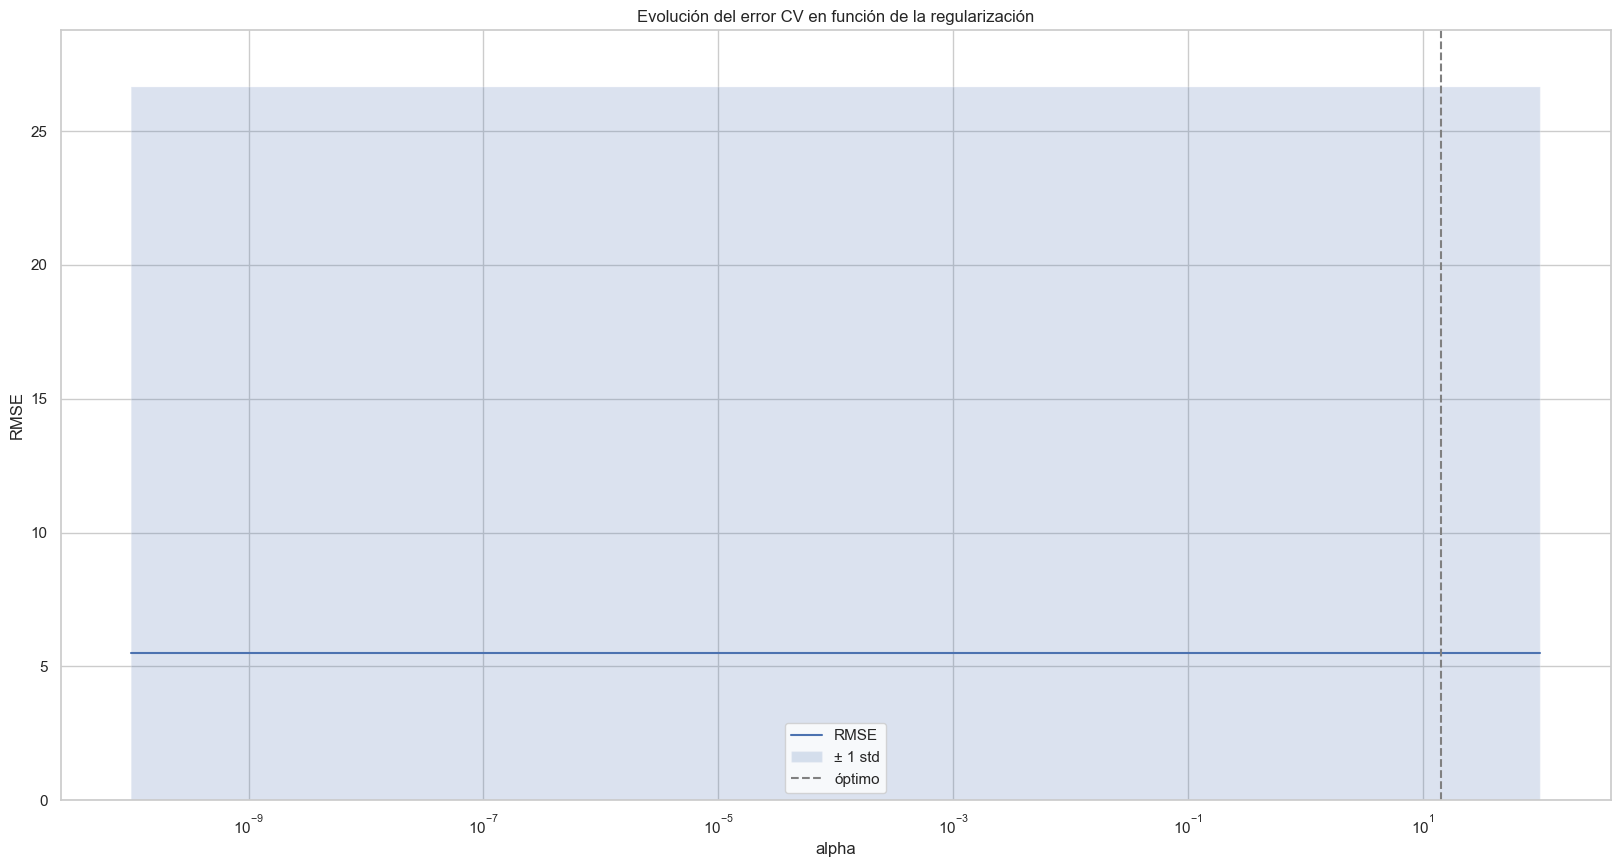

Mejor valor de alpha encontrado: 14.314589375234757


In [ ]:
# === GRÁFICO DEL ERROR +- 1 DESVIACIÓN ESTÁNDAR ===
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(modelo.alphas, rmse_cv, label='RMSE')
ax.fill_between(
    modelo.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2,
    label='± 1 std'
)

ax.axvline(x=optimo, c="gray", linestyle='--', label='óptimo')

ax.set_xscale('log')
ax.set_ylim([0, None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()
plt.show()

print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

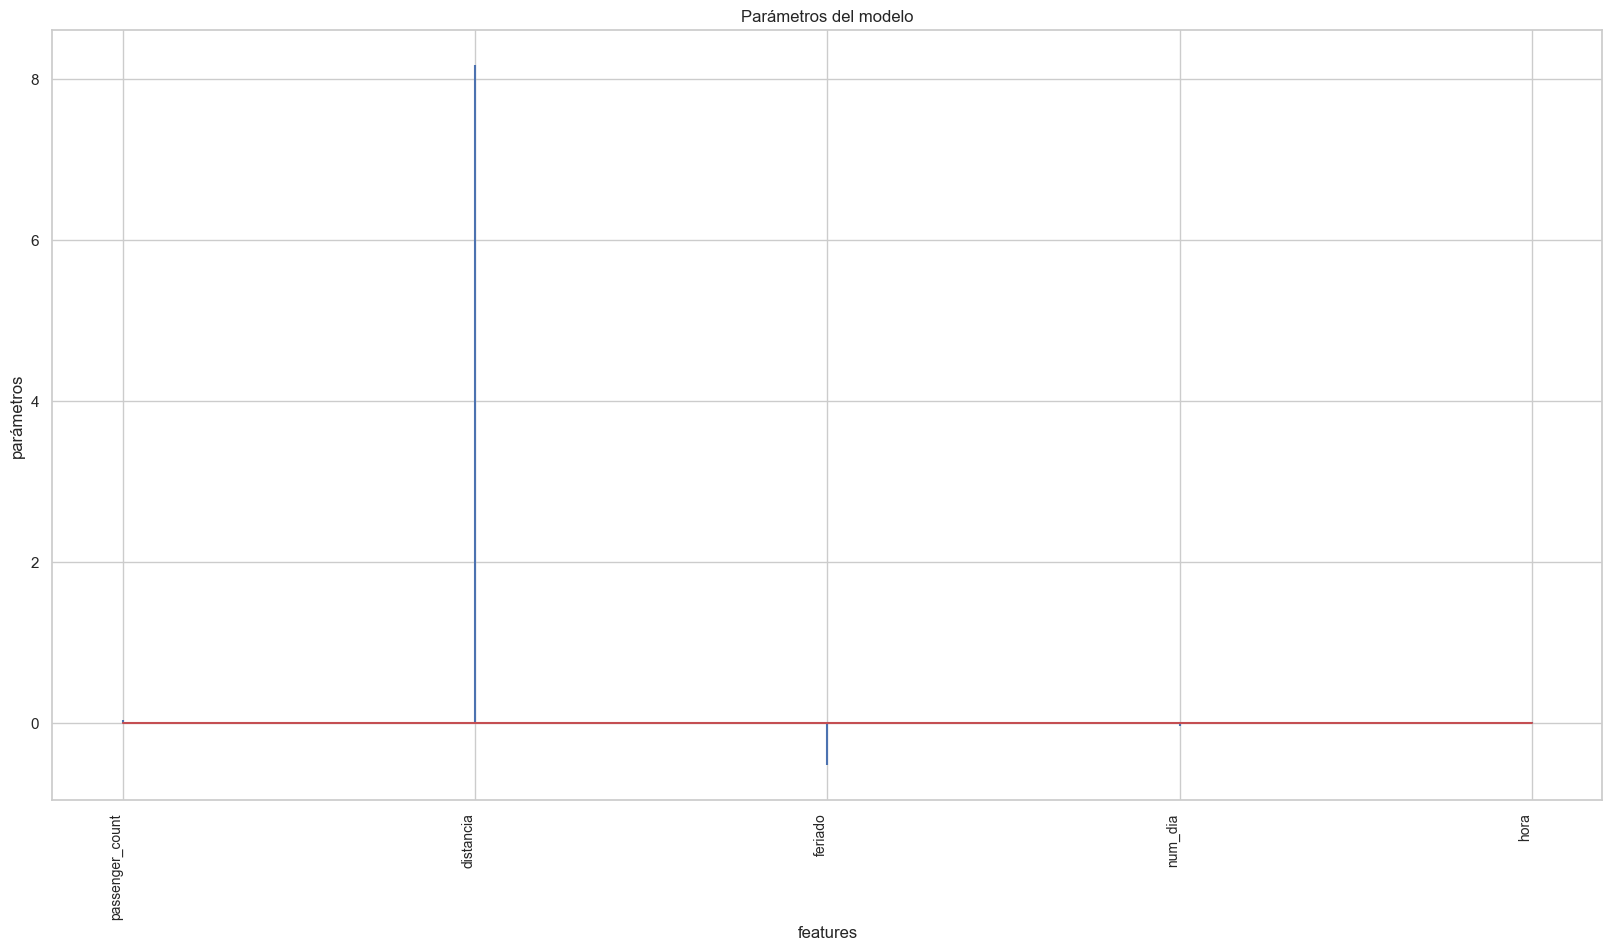

In [ ]:
# === PARÁMETROS DEL MODELO ===
df_coeficientes = pd.DataFrame(
    {'predictor': X_train.columns,  # asegurate que X_train sea un DataFrame y no un array
        'coef': modelo.coef_.flatten()}
)

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
grafico_texto("Parámetros del modelo","features","parámetros")

In [ ]:
# === PREDICCIONES EN TEST ===
prediccionRidge = modelo.predict(X_test).flatten()
prediccionRidge[:10]

array([ 6.97273893, 10.73888792, 11.46382269, 13.05620597, 11.07560634,
       17.22199051,  7.25400742, 21.64655038,  8.10725173, 12.42237638])

In [ ]:
# === ERROR DEL MODELO EN TEST ===

print_metrics(y_test, prediccionRidge, "Prueba (Ridge)")

--- Prueba (Ridge) ---
R2 Score: 0.6956989076856357
MSE: 27.828634715133763
RMSE: 5.275285273341505
MAE: 2.577474546462137


### Variación hiperparámetros de Ridge

In [ ]:
def grafico_plot(data: pd.DataFrame,
                    x: str,
                    y: str,
                    xscale : str,
                    title: str,
                    xlabel: str,
                    ylabel: str,
                    grid: bool,
                    tight_layout: bool = False):
    plt.figure(figsize=(12, 6))
    plt.plot(data[x], data[y], marker='o')
    plt.xscale(xscale)
    grafico_texto(title,xlabel,ylabel,grid, tight_layout = tight_layout)

NameError: name 'pd' is not defined

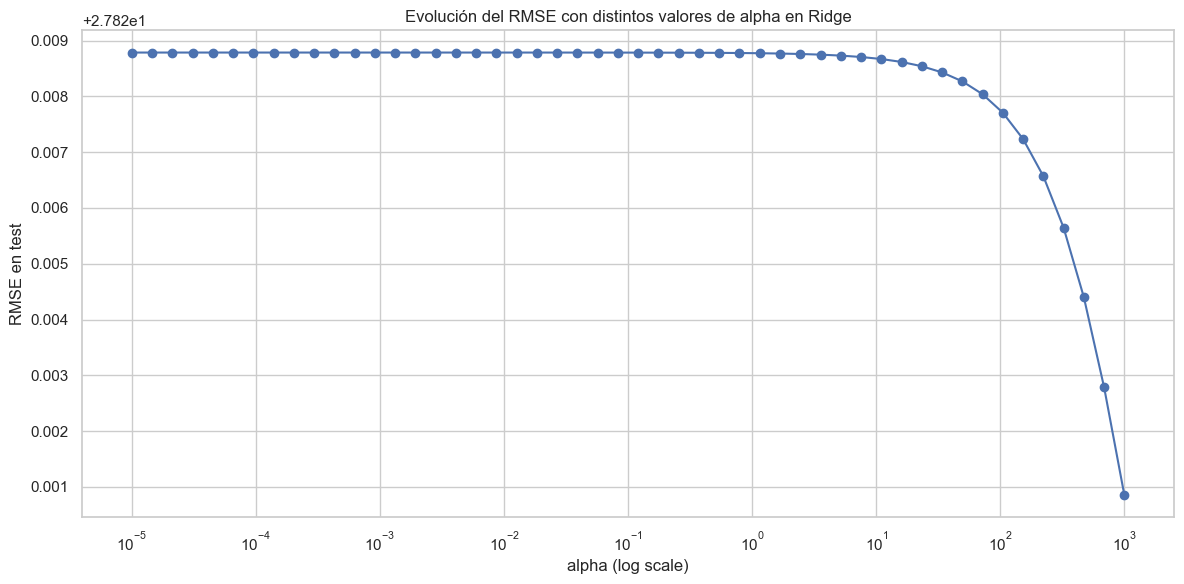

In [ ]:
# Valores de alpha a testear (desde muy baja hasta alta regularización)
valores_alpha = np.logspace(-5, 3, 50)  # de 10^-5 a 10^3

# Lista para guardar los RMSEs
rmse_alphas = []

# Entrenamiento y evaluación por cada alpha
for alpha in valores_alpha:
    modelo_ridge = Ridge(alpha=alpha)
    modelo_ridge.fit(X_train, y_train)
    predicciones = modelo_ridge.predict(X_test)
    rmse = mean_squared_error(y_test, predicciones)
    rmse_alphas.append(rmse)

# Convertir a DataFrame para análisis o visualización
df_ridge_alphas = pd.DataFrame({
    'alpha': valores_alpha,
    'rmse': rmse_alphas
})

# Gráfico
grafico_plot(df_ridge_alphas, 'alpha', 'rmse', "log",
                "Evolución del RMSE con distintos valores de alpha en Ridge",
                "alpha (log scale)",
                "RMSE en test",
                True, True)

### Lasso Regression

In [ ]:
# === MODELO LASSO CON CROSS-VALIDATION ===
modelo = LassoCV(
    alphas=np.logspace(-10, 3, 200),
    cv=10
).fit(X=X_train, y=y_train.to_numpy().flatten())

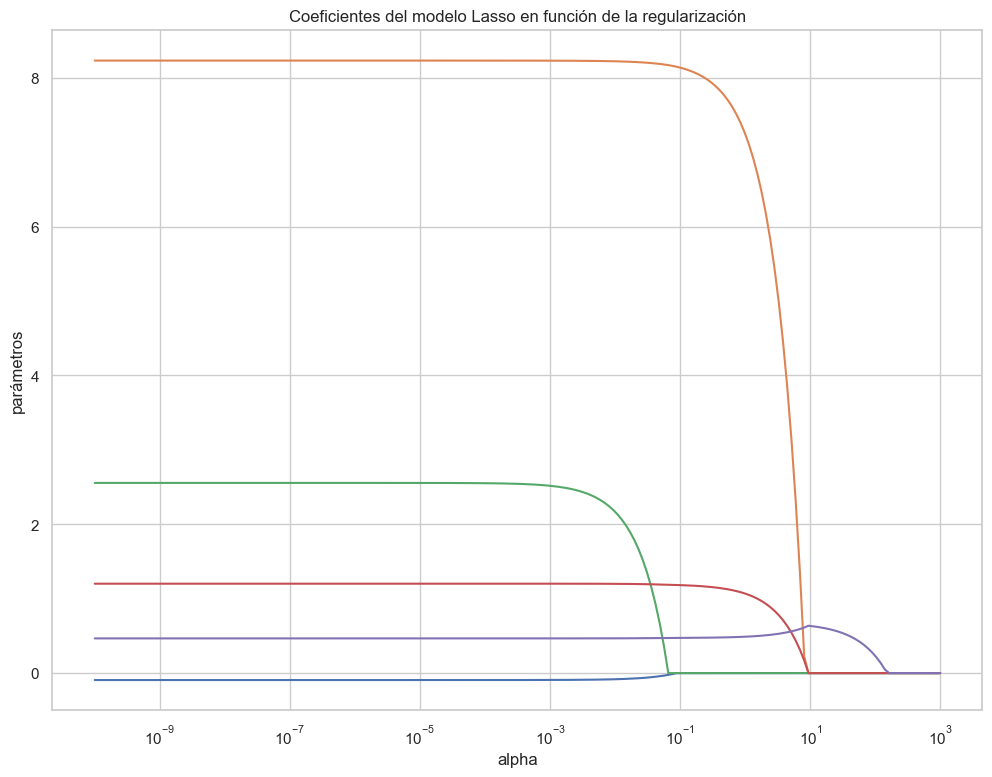

In [ ]:
# === EVOLUCIÓN DE LOS PARÁMETROS EN FUNCIÓN DE ALPHA ===
alphas = modelo.alphas_
coefs = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(12, 8.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_ylim([-0.5, None])
grafico_texto("Coeficientes del modelo Lasso en función de la regularización", 'alpha', 'parámetros')

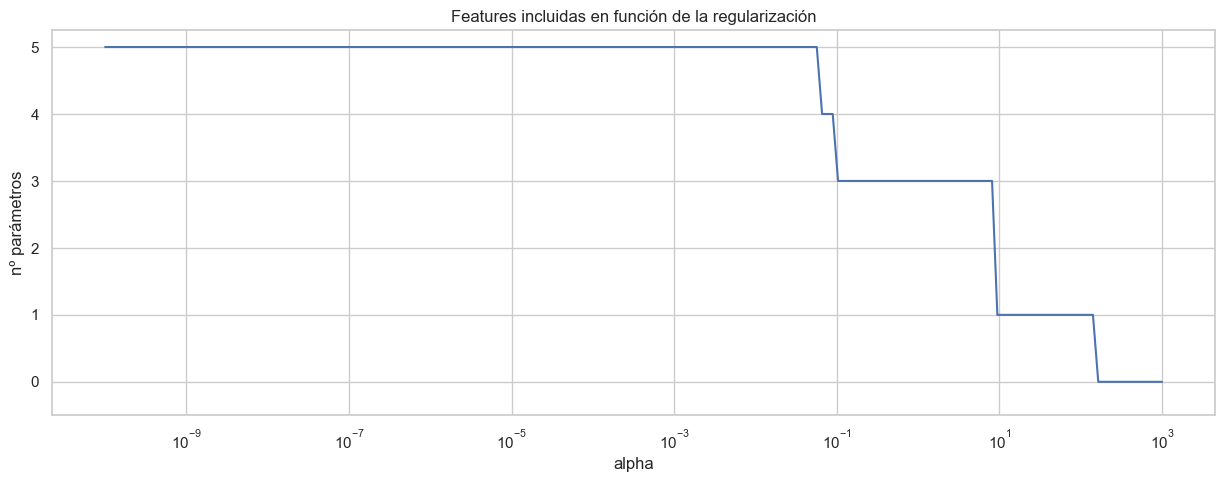

In [ ]:
# === Nº DE FEATURES INCLUIDAS EN FUNCIÓN DE ALPHA ===
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-0.5, None])
grafico_texto('Features incluidas en función de la regularización', 'alpha', 'nº parámetros')

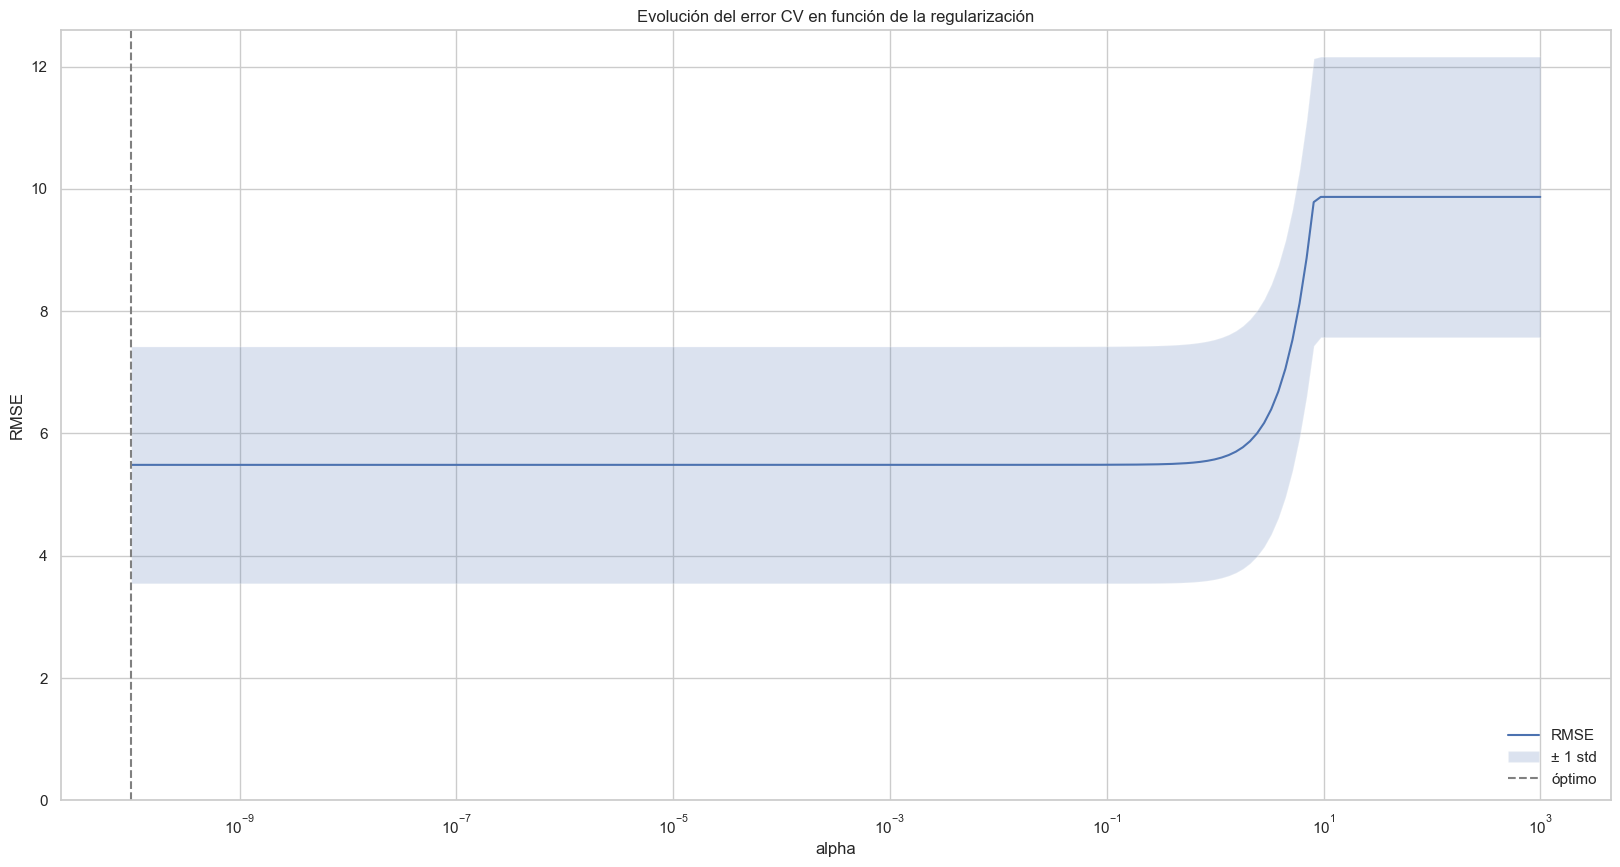

Mejor valor de alpha encontrado: 1e-10


In [ ]:
# === EVOLUCIÓN DEL ERROR DE VALIDACIÓN CRUZADA ===
mse_cv = modelo.mse_path_.mean(axis=1)
mse_sd = modelo.mse_path_.std(axis=1)

rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

min_rmse = np.min(rmse_cv)
optimo = modelo.alphas_[np.argmin(rmse_cv)]

fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(modelo.alphas_, rmse_cv, label='RMSE')
ax.fill_between(
    modelo.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2,
    label='± 1 std'
)
ax.axvline(x=optimo, c="gray", linestyle='--', label='óptimo')

ax.set_xscale('log')
ax.set_ylim([0, None])
grafico_texto('Evolución del error CV en función de la regularización', 'alpha', 'RMSE', legend = True)

print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

         predictor      coef
0  passenger_count  0.037693
1        distancia  8.182981
2          feriado -0.524322
3          num_dia -0.036878
4             hora  0.006320


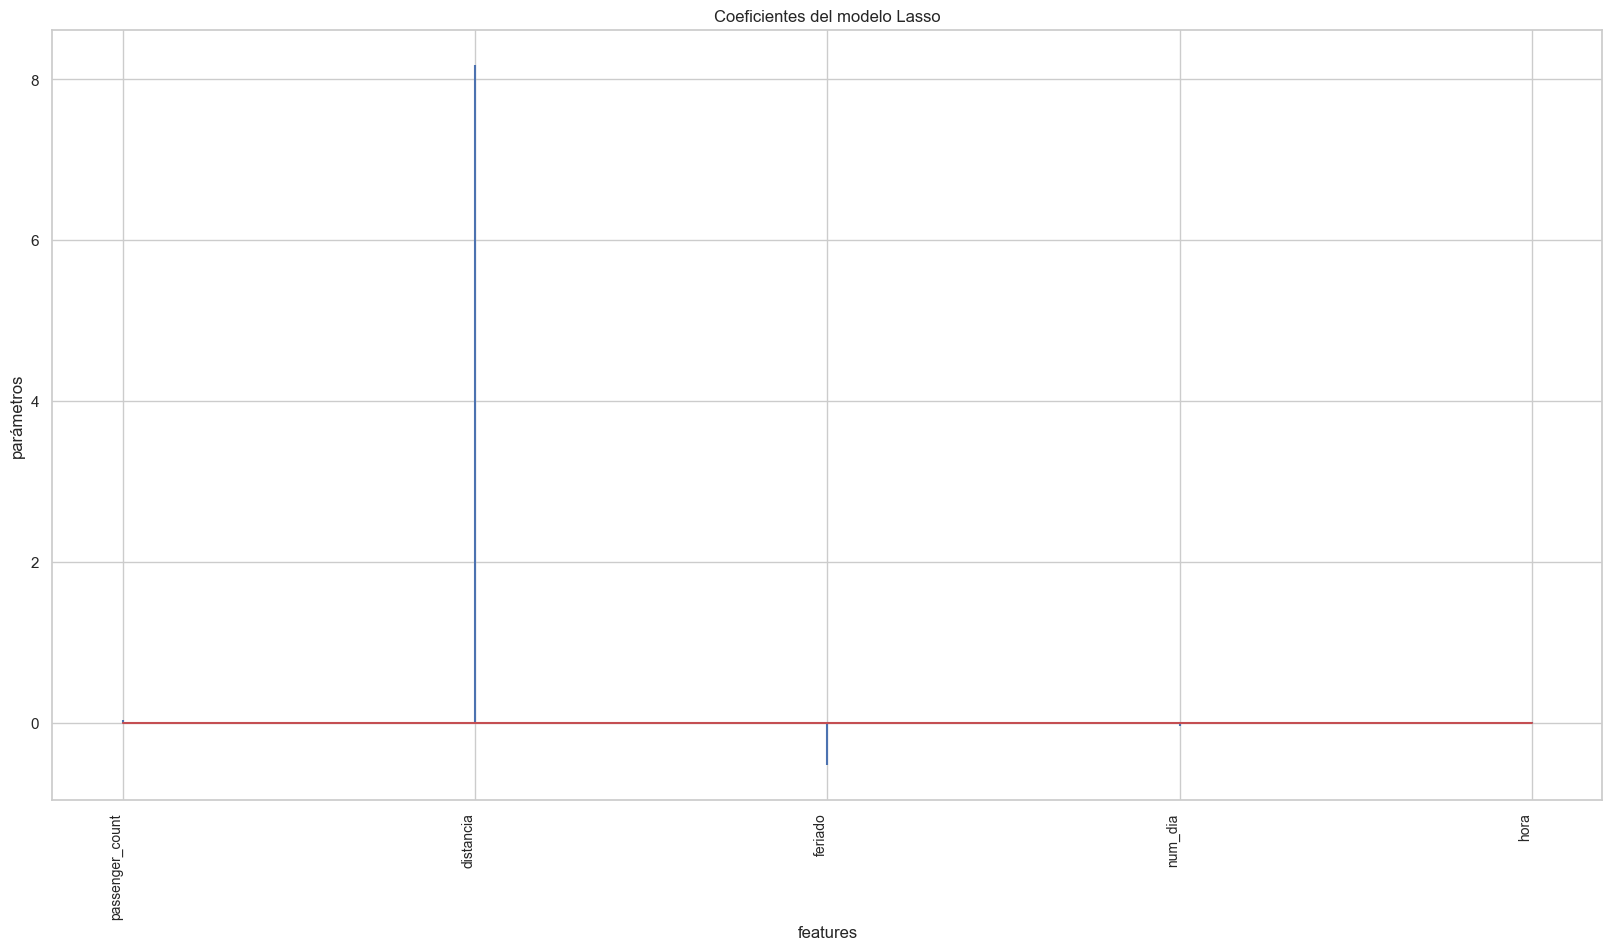

In [ ]:
# === COEFICIENTES DEL MODELO ===
df_coeficientes = pd.DataFrame({
    'predictor': X_train.columns,  # asegurate que X_train sea DataFrame
    'coef': modelo.coef_.flatten()
})

# Mostrar sólo los coeficientes distintos de 0
print(df_coeficientes[df_coeficientes.coef != 0])

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
grafico_texto("Coeficientes del modelo Lasso", "features", "parámetros")

In [ ]:
# === PREDICCIONES EN TEST ===
prediccionLasso = modelo.predict(X=X_test).flatten()
predicciones[:10]

array([ 6.99475529, 10.74010704, 11.46344046, 13.0439414 , 11.07717323,
       17.18296933,  7.27928799, 21.57860767,  8.12345132, 12.4135988 ])

In [ ]:
# === ERROR EN TEST ===

print_metrics(y_test, prediccionLasso, "Prueba (Lasso)")

--- Prueba (Lasso) ---
R2 Score: 0.6956972584868777
MSE: 27.82878553598512
RMSE: 5.275299568364352
MAE: 2.5774229823453907


### Variación de hiperparámetros en Lasso

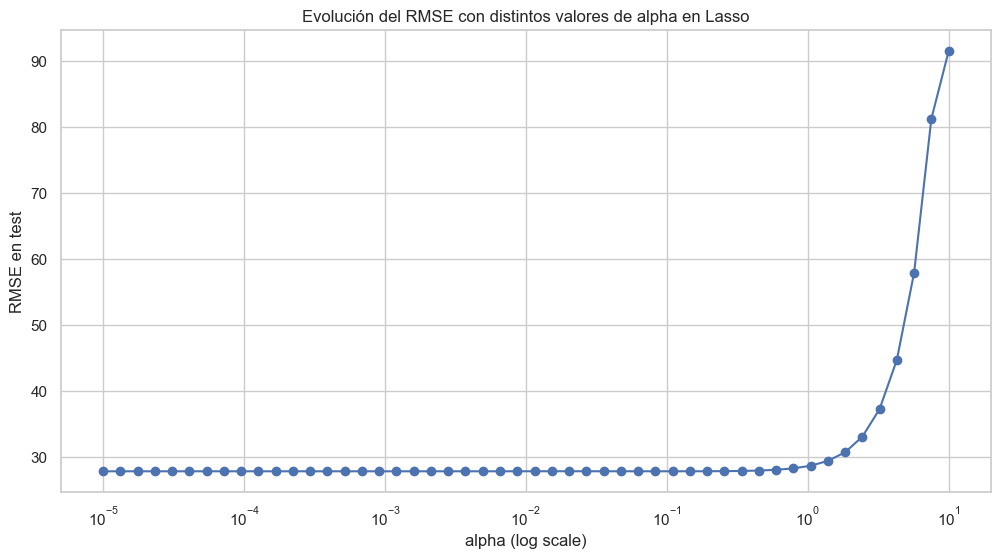

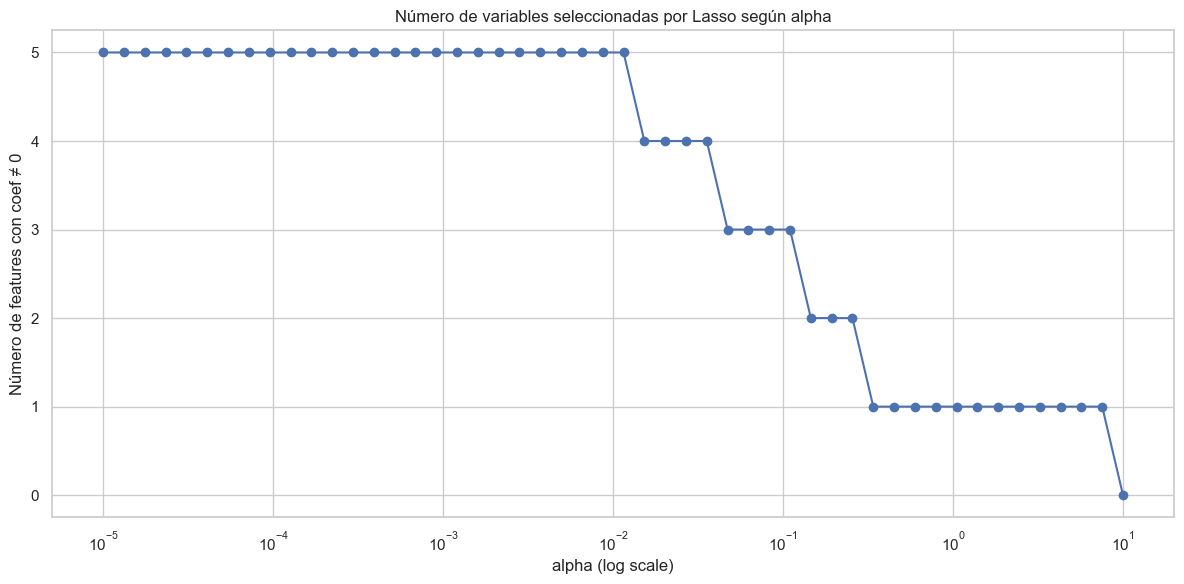

In [ ]:
# Valores de alpha a testear
valores_alpha = np.logspace(-5, 1, 50)  # desde 10^-5 a 10^1

# Listas para guardar métricas
rmse_lasso_list = []
n_features_usadas = []

# Entrenar Lasso para cada alpha
for alpha in valores_alpha:
    modelo_lasso = Lasso(alpha=alpha, max_iter=10000)
    modelo_lasso.fit(X_train, y_train)
    predicciones = modelo_lasso.predict(X_test)
    
    # RMSE
    rmse = mean_squared_error(y_test, predicciones)
    rmse_lasso_list.append(rmse)
    
    # Contar cuántos coeficientes no son cero (features usadas)
    n_features_usadas.append(np.sum(modelo_lasso.coef_ != 0))

# Crear DataFrame para análisis
df_lasso_alphas = pd.DataFrame({
    'alpha': valores_alpha,
    'rmse': rmse_lasso_list,
    'features_usadas': n_features_usadas
})

# === Gráfico 1: RMSE vs alpha ===
grafico_plot(df_lasso_alphas,
            'alpha',
            'rmse',
            'log',
            'Evolución del RMSE con distintos valores de alpha en Lasso',
            'alpha (log scale)',
            'RMSE en test',
            True)

# === Gráfico 2: Cantidad de features usadas vs alpha ===
grafico_plot(df_lasso_alphas,
            'alpha',
            'features_usadas',
            'log',
            'Número de variables seleccionadas por Lasso según alpha',
            'alpha (log scale)',
            'Número de features con coef ≠ 0',
            True, True)

###  Trayectoria de coeficientes (coef vs alpha) en Lasso

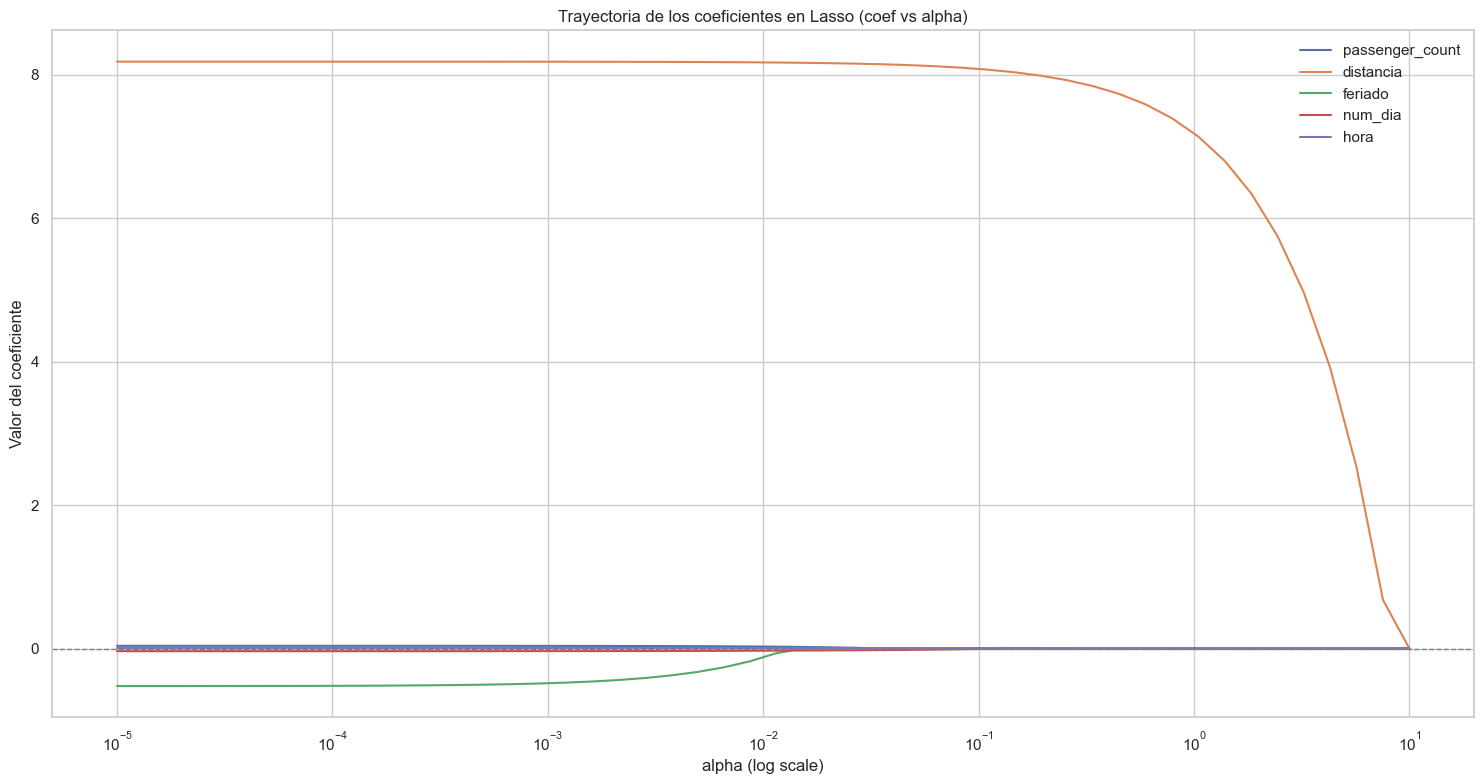

In [ ]:
# Asegurate de que X_train sea un DataFrame para tener los nombres de las columnas
nombres_features = X_train.columns if hasattr(X_train, 'columns') else [f"X{i}" for i in range(X_train.shape[1])]

# Alphas y coeficientes
valores_alpha = np.logspace(-5, 1, 50)
coefs = []

for alpha in valores_alpha:
    modelo_lasso = Lasso(alpha=alpha, max_iter=10000)
    modelo_lasso.fit(X_train, y_train)
    coefs.append(modelo_lasso.coef_)

# Convertimos a array para facilitar el plot
coefs = np.array(coefs)

# === Gráfico ===
plt.figure(figsize=(15, 8))
for i in range(coefs.shape[1]):
    plt.plot(valores_alpha, coefs[:, i], label=nombres_features[i])

plt.xscale('log')
grafico_texto('Trayectoria de los coeficientes en Lasso (coef vs alpha)',
                'alpha (log scale)',
                'Valor del coeficiente',
                True, False, [], 0, True, True, True)

### ElasticNet

In [ ]:
# === ENTRENAMIENTO DEL MODELO ===
modelo = ElasticNetCV(
    l1_ratio=[0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    alphas=np.logspace(-10, 3, 200),
    cv=10
).fit(X=X_train, y=y_train.to_numpy().flatten())

c:\Users\fabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\fabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7045741.721977206, tolerance: 1410.1494086128905
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\fabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\fabri\AppData\

In [ ]:
# === ERROR MEDIO DE CV PARA CADA COMBINACIÓN ===
mean_error_cv = modelo.mse_path_.mean(axis=2)

df_resultados_cv = pd.DataFrame(
    data=mean_error_cv.flatten(),
    index=pd.MultiIndex.from_product(
        iterables=[modelo.l1_ratio, modelo.alphas_],
        names=['l1_ratio', 'modelo.alphas_']
    ),
    columns=["mse_cv"]
)

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending=True)
df_resultados_cv.head()

,l1_ratio,modelo.alphas_,mse_cv,rmse_cv
108,0.0,0.000088,30.093061,5.485714
109,0.0,0.000076,30.093061,5.485714
107,0.0,0.000102,30.093061,5.485714
110,0.0,0.000065,30.093061,5.485714
308,0.1,0.000088,30.093061,5.485714


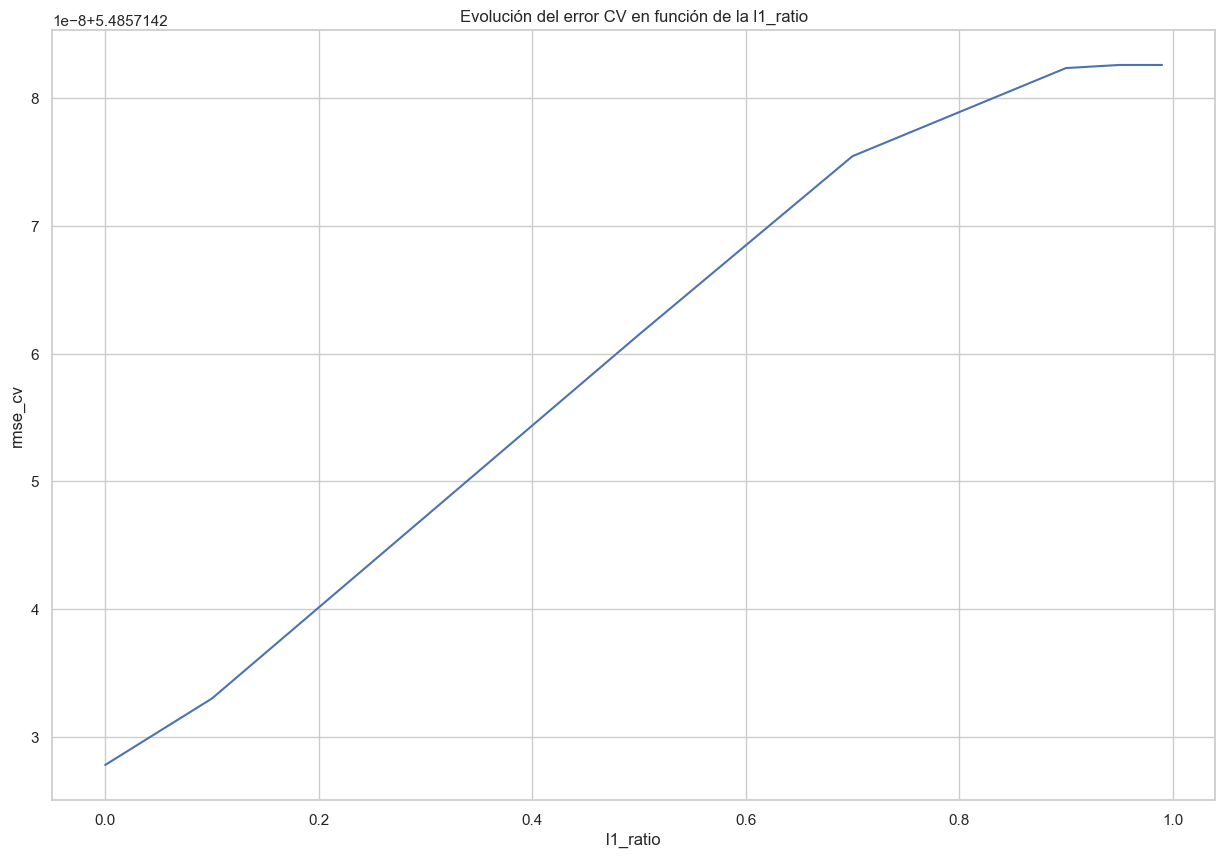

In [ ]:
# === GRÁFICO: RMSE vs l1_ratio ===
fig, ax = plt.subplots(figsize=(15, 10))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax=ax)
grafico_texto(
    title='Evolución del error CV en función de la l1_ratio',
    xlabel='l1_ratio',
    ylabel='rmse_cv')


In [ ]:
# === MEJOR ALPHA Y l1_ratio ===
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")
print(f"Mejor valor de l1_ratio encontrado: {modelo.l1_ratio_}")

Mejor valor de alpha encontrado: 8.804883581643464e-05
Mejor valor de l1_ratio encontrado: 0.0


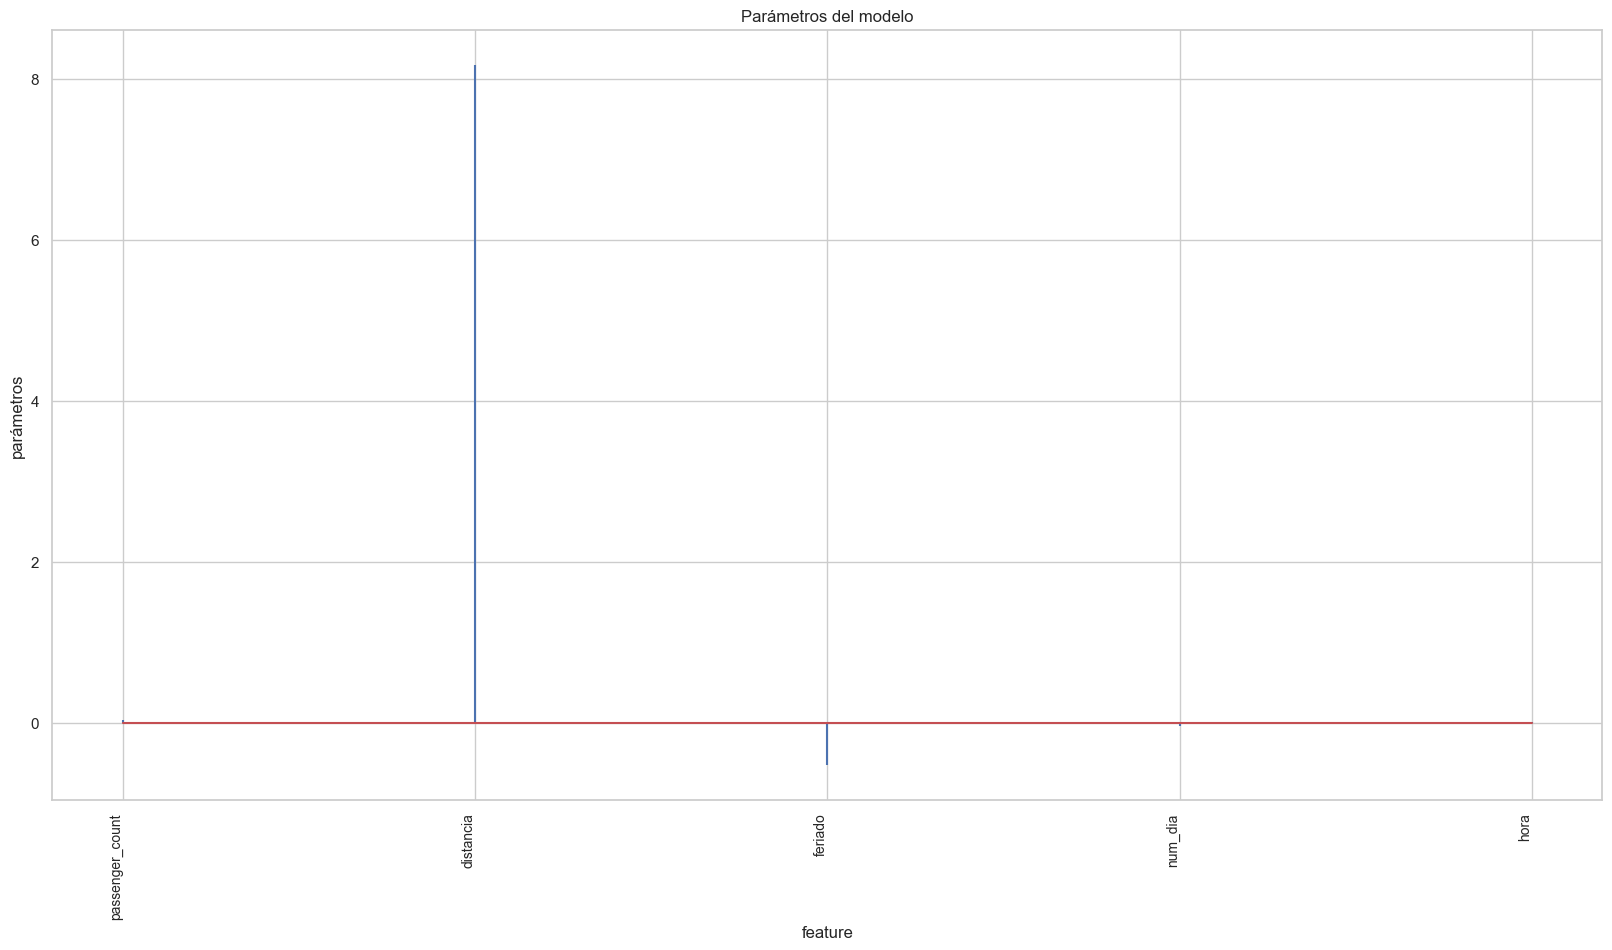

In [ ]:
# === COEFICIENTES DEL MODELO ===
df_coeficientes = pd.DataFrame({
    'predictor': X_train.columns,
    'coef': modelo.coef_.flatten()
})

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo')
plt.show()

In [ ]:
# === PREDICCIONES ===
prediccionEN = modelo.predict(X=X_test).flatten()
print(prediccionEN[:10])

[ 6.97273397 10.73888772 11.46382284 13.05620886 11.07560603 17.22199977
  7.25400173 21.64656642  8.10724808 12.42237866]


In [ ]:
# === MÉTRICAS ===
print_metrics(y_test, prediccionEN, "Prueba (ElasticNet)")

--- Prueba (ElasticNet) ---
R2 Score: 0.6956988814516056
MSE: 27.828637114261674
RMSE: 5.275285500734692
MAE: 2.5774737226434077


### Comparación de modelos por RMSE

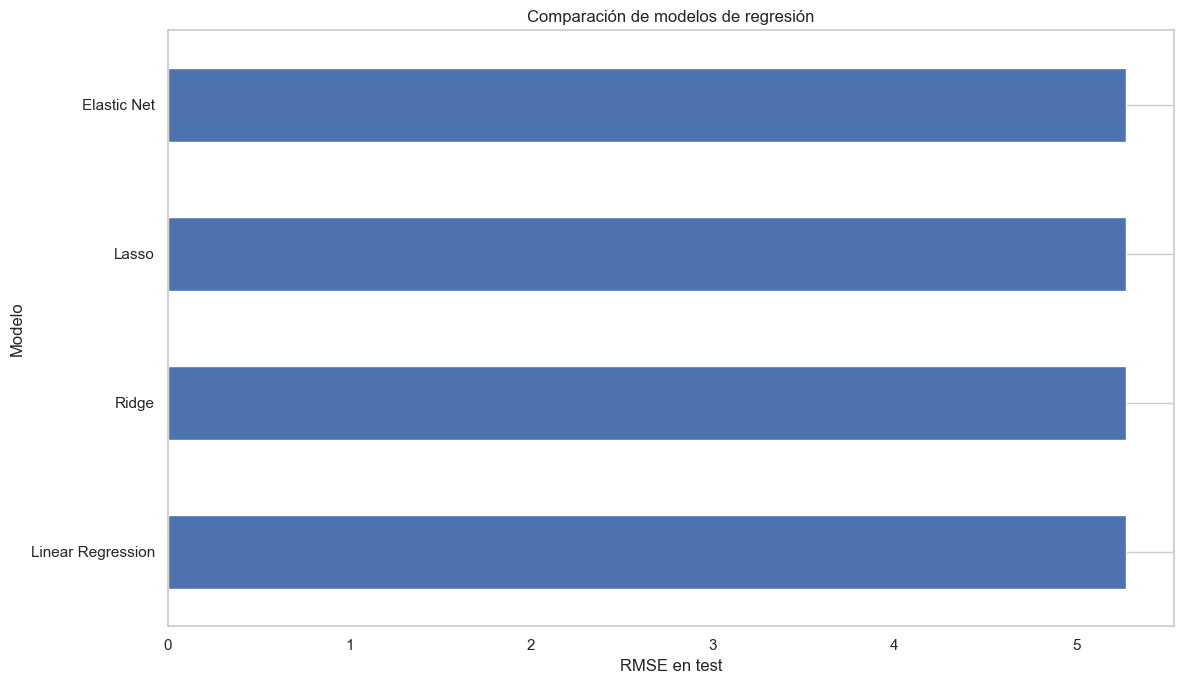

,modelo,test_rmse
1,Ridge,5.275285
3,Elastic Net,5.275286
0,Linear Regression,5.275300
2,Lasso,5.275300


In [ ]:
# === COMPARACIÓN FINAL DE MODELOS ===
df_comparacion = pd.DataFrame({
    'modelo': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'test_rmse': [ np.sqrt(mean_squared_error(y_test, y_pred_test_lr)), 
                   np.sqrt(mean_squared_error(y_test, prediccionRidge)), 
                   np.sqrt(mean_squared_error(y_test, prediccionLasso)), 
                   np.sqrt(mean_squared_error(y_test, prediccionEN))]
})

fig, ax = plt.subplots(figsize=(12, 7))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax, legend=False)
ax.set_xlabel('RMSE en test')
ax.set_ylabel('Modelo')
ax.set_title('Comparación de modelos de regresión')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

df_comparacion.sort_values(by='test_rmse')

### Conclusión

A lo largo del proyecto de regresión, se desarrolló un análisis completo que abarcó desde la limpieza de los datos hasta la comparación de modelos. Este proceso no solo permitió entrenar distintos algoritmos de regresión, sino que también dejó en evidencia desafíos reales del trabajo con datos reales y masivos, además de las decisiones críticas de preprocesamiento que hemos tomado e influyen directamente en la capacidad predictiva del modelo.

Uno de los aspectos más delicados fue la validación y tratamiento de las coordenadas geográficas (pickup y dropoff) y su derivada: la distancia. Se estableció un rango razonable para estos valores, lo cual fue fundamental para eliminar e imputar registros atípicos. Para la imputación, en un principio se hizo mediante KNN Imputer, pero su alto costo computacional (incluso de una hora de ejecución en nuestras computadoras personales) y su impacto casi nulo en la mejora de métricas nos llevó a optar por una imputación más eficiente: la mediana.

Otro punto relevante fue el tratamiento de outliers, especialmente en la variable objetivo fare_amount. Durante la limpieza fuimos detectando valores extremos. Si bien algunos eran errores evidentes (como valores negativos o tarifas desproporcionadas respecto a la distancia), otros casos representaban viajes legítimos con tarifas elevadas. En este caso, en lugar de eliminar por completo estos registros —y sesgar el modelo hacia la media—, optamos por preservarlos, aceptando el riesgo de que influyan en las métricas finales. Esta decisión respeta la distribución real de los datos y aporta robustez en escenarios reales donde las predicciones pueden incluir extremos.

Uno de los debates más importantes fue cuándo dividir el conjunto en train y test. Optar por dividir antes de limpiar garantiza que el conjunto de test no sea tocado, pero puede introducir inconsistencias si no se le aplican las mismas reglas. Por otro lado, limpiar todo el dataset y luego dividirlo puede introducir una fuga de información. Finalmente, decidimos limpiar primero y dividir después, priorizando la coherencia de los datos y la calidad de las variables imputadas y transformadas.

Durante la evaluación de modelos vimos que todos: Linear Regression, Ridge, Lasso y Elastic Net, dieron resultados prácticamente idénticos, con un RMSE cercano a 5.27 y un coeficiente de R² de aproximadamente 0.695. Este comportamiento nos llamó mucho la atención, peor observando bien nos dimos cuenta de que era posible y tiene una justificación técnica. En primer lugar, la variable “distancia” demostró tener un peso predictivo mucho mayor que el resto (se puede observar en los gráficos hechos), siendo responsable principal del valor de fare_amount. Y eso se reflejó en todos los modelos, especialmente en Lasso, donde al aumentar el parámetro de regularización alpha, las demás variables fueron eliminadas del modelo y sólo “distancia” se mantuvo hasta valores elevados de alpha. Además, el impacto de la regularización resultó ser casi nulo: tanto en Ridge como en Lasso, los valores óptimos de alpha encontrados mediante validación cruzada fueron extremadamente bajos, lo cual indica que la penalización aplicada fue mínima, haciendo que los modelos regularizados se comportaran casi de manera idéntica a la regresión lineal clásica. Los gráficos de evolución de coeficientes y del RMSE en función de alpha confirmaron el patrón, mostrando trayectorias planas y errores estables. Y también debermos considerar que el problema tiene sólo cinco variables predictoras y relaciones lineales claras, lo que reduce la necesidad y el beneficio de utilizar técnicas de regularización como Lasso o Elastic Net, donde su valor se refleja más en contextos de alta dimensionalidad o presencia de colinealidades severas. Entonces, en este caso específico, los modelos de regresión no aportaron mejoras sustanciales.

En conclusión, el modelo puede explicar el 0,695 de la varianza de la variable target, lo cual consideramos bastante satisfactorio teniendo en cuenta las decisiones tomadas en la limpieza e imputación de los datos. También se puede considerar que R2 de casi un 0,70 es bastante bueno y capta correctamente los patrones generales, aunque hay un 30% de variabilida no explicada, además de atribuírselo a las decisiones tomadas en la fase inicial del EDA, también podría deberse a factores no considerados como el clima, el tráfico etc.